1st column is the acceleration data in the X axis measured by the sensor ADXL345.
2nd column is the acceleration data in the Y axis measured by the sensor ADXL345.
3rd column is the acceleration data in the Z axis measured by the sensor ADXL345.

4th column is the rotation data in the X axis measured by the sensor ITG3200.
5th column is the rotation data in the Y axis measured by the sensor ITG3200.
6th column is the rotation data in the Z axis measured by the sensor ITG3200.

7th column is the acceleration data in the X axis measured by the sensor MMA8451Q.
8th column is the acceleration data in the Y axis measured by the sensor MMA8451Q.
9th column is the acceleration data in the Z axis measured by the sensor MMA8451Q.

File name format:
**<ADL OR FALL_CODE>_<SUBJECT_ID>_<TRIAL_NO>.txt**

**Activities of Daily Living (ADL):**

<!-- <div align="center"> -->

| Code | Activity                                                                                 | Trials | Duration |
|:----:|------------------------------------------------------------------------------------------|:------:|:--------:|
| D01  | Walking slowly                                                                           | 1      | 100s     |
| D02  | Walking quickly                                                                          | 1      | 100s     |
| D03  | Jogging slowly                                                                           | 1      | 100s     |
| D04  | Jogging quickly                                                                          | 1      | 100s     |
| D05  | Walking upstairs and downstairs slowly                                                   | 5      | 25s      |
| D06  | Walking upstairs and downstairs quickly                                                  | 5      | 25s      |
| D07  | Slowly sit in a half height chair, wait a moment, and up slowly                          | 5      | 12s      |
| D08  | Quickly sit in a half height chair, wait a moment, and up quickly                        | 5      | 12s      |
| D09  | Slowly sit in a low height chair, wait a moment, and up slowly                           | 5      | 12s      |
| D10  | Quickly sit in a low height chair, wait a moment, and up quickly                         | 5      | 12s      |
| D11  | Sitting a moment, trying to get up, and collapse into a chair                            | 5      | 12s      |
| D12  | Sitting a moment, lying slowly, wait a moment, and sit again                             | 5      | 12s      |
| D13  | Sitting a moment, lying quickly, wait a moment, and sit again                            | 5      | 12s      |
| D14  | Being on one's back change to lateral position, wait a moment, and change to one's back  | 5      | 12s      |
| D15  | Standing, slowly bending at knees, and getting up                                        | 5      | 12s      |
| D16  | Standing, slowly bending without bending knees, and getting up                           | 5      | 12s      |
| D17  | Standing, get into a car, remain seated and get out of the car                           | 5      | 25s      |
| D18  | Stumble while walking                                                                    | 5      | 12s      |
| D19  | Gently jump without falling (trying to reach a high object)                              | 5      | 12s      |


Falls:

| Code | Activity                                                                                 | Trials | Duration |
|:----:|------------------------------------------------------------------------------------------|:------:|:--------:|
| F01  | Fall forward while walking caused by a slip                                              | 5      | 15s      |
| F02  | Fall backward while walking caused by a slip                                             | 5      | 15s      |
| F03  | Lateral fall while walking caused by a slip                                              | 5      | 15s      |
| F04  | Fall forward while walking caused by a trip                                              | 5      | 15s      |
| F05  | Fall forward while jogging caused by a trip                                              | 5      | 15s      |
| F06  | Vertical fall while walking caused by fainting                                           | 5      | 15s      |
| F07  | Fall while walking, with use of hands in a table to dampen fall, caused by fainting      | 5      | 15s      |
| F08  | Fall forward when trying to get up                                                       | 5      | 15s      |
| F09  | Lateral fall when trying to get up                                                       | 5      | 15s      |
| F10  | Fall forward when trying to sit down                                                     | 5      | 15s      |
| F11  | Fall backward when trying to sit down                                                    | 5      | 15s      |
| F12  | Lateral fall when trying to sit down                                                     | 5      | 15s      |
| F13  | Fall forward while sitting, caused by fainting or falling asleep                         | 5      | 15s      |
| F14  | Fall backward while sitting, caused by fainting or falling asleep                        | 5      | 15s      |
| F15  | Lateral fall while sitting, caused by fainting or falling asleep                         | 5      | 15s      |
<!-- </div> -->

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# import os
# import zipfile
import functions as fn
import pandas as pd

In [2]:
# Path to zip file
zip_file_path = '/Volumes/Windows SD/Master SSE/Semester 2/Fall Detection/DataSet.zip'

# zip_file_path = "DataSet/SisFall_dataset.zip"

# Base path to the dataset folder structure *inside* the zip file
# base_path = 'SisFall_dataset'
base_path = 'DataSet/SisFall_dataset'

# Create list of folder names (SA01 to SA23 and SE01 to SE15)
subject_ids = [f'SA{str(i).zfill(2)}' for i in range(1, 24)] + [f'SE{str(i).zfill(2)}' for i in range(1, 16)]


# all_data, all_labels, activity_code_list, adls, falls = fn.read_file(base_path, subject_ids)
all_data, all_labels, activity_code_list, file_name_list, adls, falls = fn.read_zip(zip_file_path, base_path, subject_ids)

print(f'number of total readings: {len(all_data)}')
print(f'number of total labels: {len(all_labels)}')
print(f'number of total activity codes: {len(activity_code_list)}')
print(f'number of total file names: {len(file_name_list)}')
print('------------------------------------------')
print(f'number of total ADL data: {len(adls)}')
print(f'number of total Fall data: {len(falls)}')
print('------------------------------------------')
# print number of unique labels and their counts
unique_labels, counts = np.unique(all_labels, return_counts=True)
print("Unique labels and their counts:")
for label, count in zip(unique_labels, counts):
    print(f"{label}: {count}")

# create a dictionary to map activity codes to real-world activities
activity_mapping = {
    "D01": "Walking slowly",
    "D02": "Walking quickly",
    "D03": "Jogging slowly",
    "D04": "Jogging quickly",
    "D05": "Walking upstairs and downstairs slowly",
    "D06": "Walking upstairs and downstairs quickly",
    "D07": "Slowly sit in a half height chair, wait a moment, and up slowly",
    "D08": "Quickly sit in a half height chair, wait a moment, and up quickly",
    "D09": "Slowly sit in a low height chair, wait a moment, and up slowly",
    "D10": "Quickly sit in a low height chair, wait a moment, and up quickly",
    "D11": "Sitting a moment, trying to get up, and collapse into a chair ",
    "D12": "Sitting a moment, lying slowly, wait a moment, and sit again",
    "D13": "Sitting a moment, lying quickly, wait a moment, and sit again",
    "D14": "Being on one's back change to lateral position, wait a moment, and change to one's back",
    "D15": "Standing, slowly bending at knees, and getting up",
    "D16": "Standing, slowly bending without bending knees, and getting up",
    "D17": "Standing, get into a car, remain seated and get out of the car",
    "D18": "Stumble while walking",
    "D19": "Gently jump without falling (trying to reach a high object)",
    "F"  : "Fall",
    "F01": "Fall forward while walking caused by a slip",
    "F02": "Fall backward while walking caused by a slip",
    "F03": "Lateral fall while walking caused by a slip",
    "F04": "Fall forward while walking caused by a trip",
    "F05": "Fall backward while walking caused by a trip",
    "F06": "Vertical fall while walking caused by fainting",
    "F07": "Fall while walking, with use of hands in a table to dampen fall, caused by fainting",
    "F08": "Fall forward when trying to get up",
    "F09": "Lateral fall when trying to get up",
    "F10": "Fall forward when trying to sit down",
    "F11": "Fall backward when trying to sit down",
    "F12": "Lateral fall when trying to sit down",
    "F13": "Fall forward while sitting, caused by fainting or falling asleep",
    "F14": "Fall backward while sitting, caused by fainting or falling asleep",
    "F15": "Lateral fall while sitting, caused by fainting or falling asleep",
}

d01_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D01']
d01_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D01']
d02_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D02']
d02_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D02']
d03_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D03']
d03_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D03']
d04_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D04']
d04_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D04']
d05_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D05']
d05_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D05']
d06_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D06']
d06_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D06']
d07_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D07']
d07_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D07']
d08_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D08']
d08_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D08']
d09_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D09']
d09_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D09']
d10_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D10']
d10_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D10']
d11_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D11']
d11_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D11']
d12_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D12']
d12_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D12']
d13_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D13']
d13_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D13']
d14_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D14']
d14_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D14']
d15_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D15']
d15_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D15']
d16_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D16']
d16_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D16']
d17_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D17']
d17_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D17']
d18_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D18']
d18_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D18']
d19_data = [data for i, data in enumerate(all_data) if activity_code_list[i] == 'D19']
d19_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i] == 'D19']
fall_data = [data for i, data in enumerate(all_data) if activity_code_list[i].startswith('F')]
fall_file_names = [file_name_list[i] for i in range(len(file_name_list)) if activity_code_list[i].startswith('F')]



Progress: 4505/4505 files processed
Total files processed: 4505 ✅
Total ADL labels: 2707 ✅
Total Fall labels: 1798 ✅
number of total readings: 4505
number of total labels: 4505
number of total activity codes: 4505
number of total file names: 4505
------------------------------------------
number of total ADL data: 2707
number of total Fall data: 1798
------------------------------------------
Unique labels and their counts:
ADL: 2707
Fall: 1798


In [3]:

# print("--------------------------------------")
print("start processing signals")

print("---------------- Fall Data ----------------")
new_fall = fn.keep_from_peak(fall_data, 400)
print("--------------------------------------")
print("-------- D01, D02, D03, D04 --------")
new_01, d01_file_names, d01_activity_code_list = fn.split_and_add(d01_data, 800, d01_file_names)
new_02, d02_file_names, d02_activity_code_list = fn.split_and_add(d02_data, 800, d02_file_names)
new_03, d03_file_names, d03_activity_code_list = fn.split_and_add(d03_data, 800, d03_file_names)
new_04, d04_file_names, d04_activity_code_list = fn.split_and_add(d04_data, 800, d04_file_names)
print("---------------- D05 ----------------")
new_d05_data = fn.idle_remover(d05_data, 200, 30, mode='gyro')
new_05_1, new_05_2 = fn.split_and_center(new_d05_data, 800)
print("---------------- D06 ----------------")
new_d06_data = fn.idle_remover(d06_data, 150, 30, mode='acc')
new_06_1, new_06_2 = fn.split_and_center(new_d06_data, 800)
print("---------------- D07 ----------------")
# for i in range(len(d07_data)):
#     d07_data[i] = d07_data[i][:, 200:]
new_d07_data_1, new_d07_data_2 = fn.extract_from_high_amp_segments(d07_data, 100, 100, 0.3, 700, 200, 800, "gyro")
print("---------------- D08 ----------------")
new_d08_data_1, new_d08_data_2 = fn.extract_from_high_amp_segments(d08_data, 100, 100, 0.14, 500, 100, 500, "gyro")
print("---------------- D09 ----------------")
new_d09_data_1, new_d09_data_2 = fn.extract_from_high_amp_segments(d09_data, 100, 100, 0.1, 700, 100, 700, "gyro")
print("---------------- D10 ----------------")
new_d10_data_1, new_d10_data_2 = fn.extract_from_high_amp_segments(d10_data, 100, 100, 0.1, 500, 100, 500, "gyro")
print("---------------- D11 ----------------")
new_d11_data = fn.keep_from_peak(d11_data, 400)
print("---------------- D12 ----------------")
new_d12_data_1, new_d12_data_2 = fn.extract_from_high_amp_segments(d12_data, 100, 100, 0.2, 800, 200, 800, "gyro")
print("---------------- D13 ----------------")
new_d13_data_1, new_d13_data_2 = fn.extract_from_high_amp_segments(d13_data, 100, 100, 0.2, 500, 50, 500, "gyro")
print("---------------- D14 ----------------")
new_d14_data_1, new_d14_data_2 = fn.extract_from_high_amp_segments(d14_data, 100, 100, 0.15, 600, 100, 600, "gyro")
print("---------------- D15 ----------------")
new_d15_data_1, new_d15_data_2 = fn.extract_from_high_amp_segments(d15_data, 250, 250, 0.2, 700, 200, 800, "gyro")
print("---------------- D16 ----------------")
new_d16_data_1, new_d16_data_2 = fn.extract_from_high_amp_segments(d16_data, 100, 100, 0.15, 700, 200, 800, "gyro")
print("---------------- D17 ----------------")
for i in range(len(d17_data)):
    d17_data[i] = d17_data[i][:, 300:]
new_d17_data_1, new_d17_data_2 = fn.extract_from_high_amp_segments(d17_data, 300, 300, 0.3, 1000, 200, 1000, "gyro")
print("---------------- D18 ----------------")
new_d18_data = fn.keep_from_peak(d18_data, 400)
print("---------------- D19 ----------------")
new_d19_data_1, new_d19_data_2 = fn.extract_from_high_amp_segments(d19_data, 100, 100, 0.2, 400, 150, 500, "acc")

new_07_1 = fn.length_fix(new_d07_data_1, 800)
new_07_2 = fn.length_fix(new_d07_data_2, 800)
new_08_1 = fn.length_fix(new_d08_data_1, 800)
new_08_2 = fn.length_fix(new_d08_data_2, 800)
new_09_1 = fn.length_fix(new_d09_data_1, 800)
new_09_2 = fn.length_fix(new_d09_data_2, 800)
new_10_1 = fn.length_fix(new_d10_data_1, 800)
new_10_2 = fn.length_fix(new_d10_data_2, 800)
new_11_1 = fn.length_fix(new_d11_data, 800)
new_12_1 = fn.length_fix(new_d12_data_1, 800)
new_12_2 = fn.length_fix(new_d12_data_2, 800)
new_13_1 = fn.length_fix(new_d13_data_1, 800)
new_13_2 = fn.length_fix(new_d13_data_2, 800)
new_14_1 = fn.length_fix(new_d14_data_1, 800)
new_14_2 = fn.length_fix(new_d14_data_2, 800)
new_15_1 = fn.length_fix(new_d15_data_1, 800)
new_15_2 = fn.length_fix(new_d15_data_2, 800)
new_16_1 = fn.length_fix(new_d16_data_1, 800)
new_16_2 = fn.length_fix(new_d16_data_2, 800)
new_18_1 = fn.length_fix(new_d18_data, 800)
new_19_1 = fn.length_fix(new_d19_data_1, 800)
new_19_2 = fn.length_fix(new_d19_data_2, 800)


start processing signals
---------------- Fall Data ----------------
1798 files processed 
Min length: 800 
Max length: 800
--------------------------------------
-------- D01, D02, D03, D04 --------
number of new D01 data: 932 with shape: (932, 6, 800), file_names :932, activities: 932 
number of new D02 data: 964 with shape: (964, 6, 800), file_names :964, activities: 964 
number of new D03 data: 965 with shape: (965, 6, 800), file_names :965, activities: 965 
number of new D04 data: 915 with shape: (915, 6, 800), file_names :915, activities: 915 
---------------- D05 ----------------
190 files processed, Min length: 2800, Max length: 5000
190 files processed, Min length: 800, Max length: 800
190 files processed, Min length: 800, Max length: 800
---------------- D06 ----------------
118 files processed, Min length: 1350, Max length: 2550
118 files processed, Min length: 800, Max length: 800
118 files processed, Min length: 800, Max length: 800
---------------- D07 ----------------
Nu

In [ ]:
# earpiece_data = pd.read_csv('earpiece/walking_7.csv')
# e_data = earpiece_data[['X', 'Y', 'Z']].T
# e_data = e_data.values
# e_data

In [ ]:
# test_data = new_01[10]

# fig = plt.figure(figsize=(10, 10))

# plt.subplot(2, 1, 1)
# plt.plot(e_data[0][1000:1800], label='Earpiece X')
# plt.plot(e_data[1][1000:1800], label='Earpiece Y')
# plt.plot(e_data[2][1000:1800], label='Earpiece Z')
# plt.title('Earpiece Data')
# plt.xlabel('Time')
# plt.ylabel('Amplitude')
# plt.legend()
# plt.grid()

# plt.subplot(2, 1, 2)
# plt.plot(test_data[0], label='Sisfall X')
# plt.plot(test_data[1], label='Sisfall Y')
# plt.plot(test_data[2], label='Sisfall Z')
# plt.title('Sisfall Data (D01)')
# plt.xlabel('Time')
# plt.ylabel('Amplitude')
# plt.legend()
# plt.grid()
# plt.show()

In [4]:
# swap accelerometer and gyroscope X (channel 0 and 3) with Y (channel 1 and 4)
def swap_x_with_y(group):
    for i in range(len(group)):
        group[i][[0, 1], :] = group[i][[1, 0], :]  # swap Acc X with Acc Y
        group[i][[3, 4], :] = group[i][[4, 3], :]  # swap Gyro X with Gyro Y

new_01 = list(new_01)
new_02 = list(new_02)
new_03 = list(new_03)
new_04 = list(new_04)

# List of all processed signal groups to apply the replacement
all_segments = [
    new_01, new_02, new_03, new_04,
    new_05_1, new_05_2, new_06_1, new_06_2,
    new_07_1, new_07_2, new_08_1, new_08_2,
    new_09_1, new_09_2, new_10_1, new_10_2,
    new_11_1,
    new_12_1, new_12_2, new_13_1, new_13_2,
    new_14_1, new_14_2, new_15_1, new_15_2,
    new_16_1, new_16_2, new_18_1, new_19_1, new_19_2,
    new_fall  # Don't forget the fall data
]

# change to list of numpy arrays
# all_segments = [np.array(group) for group in all_segments]

# Apply the transformation to all
for group in all_segments:
    swap_x_with_y(group)


# Convert from int to float and divide first 3 rows by 256 to convert to g
for group in all_segments:
    for i in range(len(group)):
        group[i] = group[i].astype(float)             # Ensure float dtype
        group[i][0:3, :] = group[i][0:3, :] / 256.0    # Convert accel to g

print("Swapped X axis (acc/gyro) values with Y axis values in all segments.")

Swapped X axis (acc/gyro) values with Y axis values in all segments.


In [ ]:
type(new_01)

In [ ]:
test_data = new_01[10]

fig = plt.figure(figsize=(10, 10))

plt.subplot(2, 1, 1)
plt.plot(e_data[0][1000:1800], label='Earpiece X')
plt.plot(e_data[1][1000:1800], label='Earpiece Y')
plt.plot(e_data[2][1000:1800], label='Earpiece Z')
plt.title('Earpiece Data')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(test_data[0], label='Sisfall X')
plt.plot(test_data[1], label='Sisfall Y')
plt.plot(test_data[2], label='Sisfall Z')
plt.title('Sisfall Data (D01)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

In [5]:
walking_signals = list(new_01) + list(new_02)
jogging_signals = list(new_03) + list(new_04)
stairs_signals = list(new_05_1) + list(new_05_2) + list(new_06_1) + list(new_06_2)
sitting_signals = list(new_07_1) + list(new_08_1) + list(new_09_1) + list(new_10_1)
fall_signals = list(new_fall)

# only keep the first 3 channels (accel) 
walking_signals = [signal[:3, :] for signal in walking_signals]
jogging_signals = [signal[:3, :] for signal in jogging_signals]
# stairs_signals = [signal[:3, :] for signal in stairs_signals]
# sitting_signals = [signal[:3, :] for signal in sitting_signals]
fall_signals = [signal[:3, :] for signal in fall_signals]

In [6]:
# walking_signals = list(new_01) + list(new_02)
# jogging_signals = list(new_03) + list(new_04)
# stairs_signals = list(new_05_1) + list(new_05_2) + list(new_06_1) + list(new_06_2)
# sitting_signals = list(new_07_1) + list(new_08_1) + list(new_09_1) + list(new_10_1)
# fall_signals = list(new_fall)



X_list = walking_signals + jogging_signals + fall_signals
# X_list = walking_signals + jogging_signals + stairs_signals + sitting_signals + fall_signals
y_list = (
    [0] * len(walking_signals) +
    [1] * len(jogging_signals) +
    # [2] * len(stairs_signals) +
    # [3] * len(sitting_signals) +
    [2] * len(fall_signals)
)

X = np.stack(X_list)  # shape: (samples, 6, 800)
y = np.array(y_list)

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X_flat = X.reshape(X.shape[0], -1)  # Now shape = (n_samples, 4800)

# First split into train+val and test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42, stratify=y
)
# Then split train+val into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

In [ ]:
X_list[0].shape

Validation Accuracy: 0.9899
Test Accuracy: 0.9901


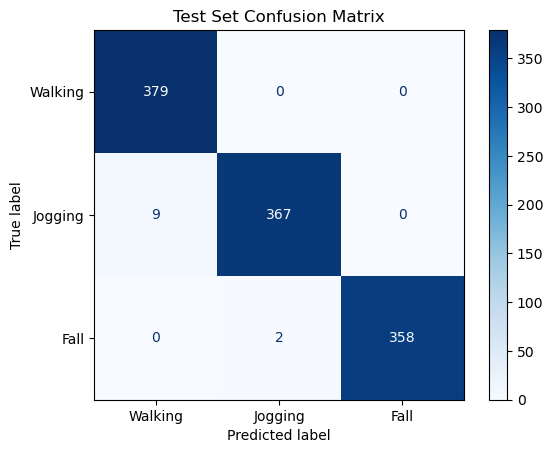

In [7]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale')  # You can tune these later
svm.fit(X_train, y_train)

val_accuracy = svm.score(X_val, y_val)
print(f"Validation Accuracy: {val_accuracy:.4f}")

test_accuracy = svm.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Predict labels on test set
y_test_pred = svm.predict(X_test)

# class_names = ["Walking", "Jogging", "Stairs", "Sitting", "Fall"]
class_names = ["Walking", "Jogging", "Fall"]
# numeric_labels = [0, 1, 2, 3, 4]  # The actual labels in your y_test
numeric_labels = [0, 1, 2]  # The actual labels in your y_test

cm = confusion_matrix(y_test, y_test_pred, labels=numeric_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)

plt.title("Test Set Confusion Matrix")
plt.show()

In [11]:
earpiece_data = pd.read_csv('earpiece/walking_7.csv')
e_data = earpiece_data[['X', 'Y', 'Z']].T
e_data = e_data.values
# e_data
# e_data.shape

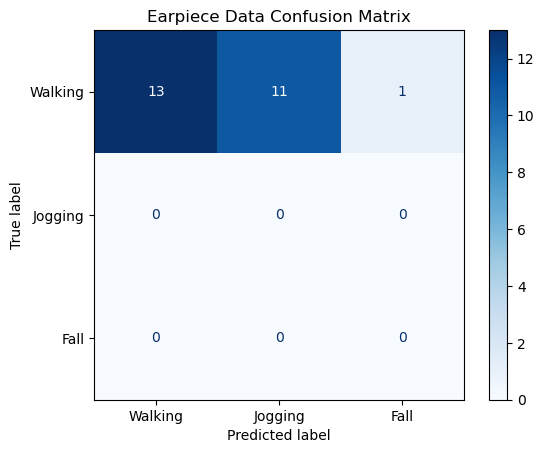

In [12]:
list_of_test_data = []
for i in range(e_data.shape[1] // 800):
    segment = e_data[:, i*800:(i+1)*800]
    list_of_test_data.append(segment.reshape(-1))  # shape: (2400,)

# Stack into a 2D array for prediction
test_data_array = np.stack(list_of_test_data)  # shape: (n_segments, 2400)

# test the model on the earpiece data
predictions = svm.predict(test_data_array)

# Convert numeric predictions back to activity names
predicted_activities = [class_names[pred] for pred in predictions]

# plot confusion matrix for earpiece data
cm_earpiece = confusion_matrix([0] * len(predicted_activities), predictions, labels=numeric_labels)
disp_earpiece = ConfusionMatrixDisplay(confusion_matrix=cm_earpiece, display_labels=class_names)
disp_earpiece.plot(cmap=plt.cm.Blues)
plt.title("Earpiece Data Confusion Matrix")
plt.show()


In [33]:

def extract_features(signal, fs=200):
    ax, ay, az = signal[1], signal[0], signal[2]
    N = signal.shape[1]
    t = np.arange(N) / fs  # time vector

    # C1: RMS of total magnitude
    C1 = np.sqrt(np.mean(ax**2 + ay**2 + az**2))

    # C2: RMS on horizontal plane (X and Z)
    C2 = np.sqrt(np.mean(ax**2 + az**2))

    # C3: Peak-to-peak RMS
    peak_to_peak = np.max(np.sqrt(ax**2 + ay**2 + az**2)) - np.min(np.sqrt(ax**2 + ay**2 + az**2))
    C3 = np.sqrt(peak_to_peak)

    # C4: Angle between z-axis and vertical
    C4 = np.mean(np.arctan2(np.sqrt(ax**2 + az**2), -ay))

    # C5: Trunk orientation
    C5 = np.std(np.arctan(np.sqrt(np.mean(ax**2 + az**2)) / np.mean(ay)))

    # C6: Orientation change in horizontal plane (mean product of ax[t-N] and ax[t])
    C6 = np.mean(ax[:-1]) * np.mean(ax[1:])

    # C7: Jerk (rate of change)
    jerk = np.diff(ax) / np.diff(t)
    C7 = np.mean(np.abs(jerk)) if len(jerk) > 0 else 0

    # C8: Std dev horizontal
    C8 = np.sqrt(np.std(ax)**2 + np.std(az)**2)

    # C9: Std dev total
    C9 = np.sqrt(np.std(ax)**2 + np.std(ay)**2 + np.std(az)**2)

    # C10: Signal Magnitude Area
    C10 = (np.sum(np.abs(ax)) + np.sum(np.abs(ay)) + np.sum(np.abs(az))) / N

    # C11: SMA horizontal
    C11 = (np.sum(np.abs(ax)) + np.sum(np.abs(az))) / N

    # C12: Activity SMA (RMS)
    C12 = np.sum(np.sqrt(ax**2 + ay**2 + az**2))

    # C13: Activity SMA on horizontal plane
    C13 = np.sum(np.sqrt(ax**2 + az**2))

    # C14: Approx velocity on horizontal plane
    vel_x = np.cumsum(ax) / fs
    vel_z = np.cumsum(az) / fs
    C14 = np.sqrt((np.sum(vel_x))**2 + (np.sum(vel_z))**2) / N

    return [C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11, C12, C13, C14]


In [34]:
feature_matrix = np.array([extract_features(s) for s in X_list])
label_vector = np.array(y_list)


In [35]:
feature_matrix.shape

(5574, 14)

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    feature_matrix, label_vector, test_size=0.2, random_state=42, stratify=label_vector
)


In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN (k=3)": KNeighborsClassifier(n_neighbors=3)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")


Random Forest Accuracy: 0.9991
Decision Tree Accuracy: 0.9991
KNN (k=3) Accuracy: 0.9946


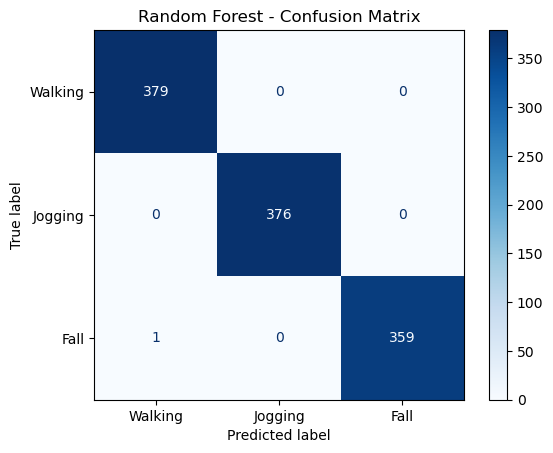

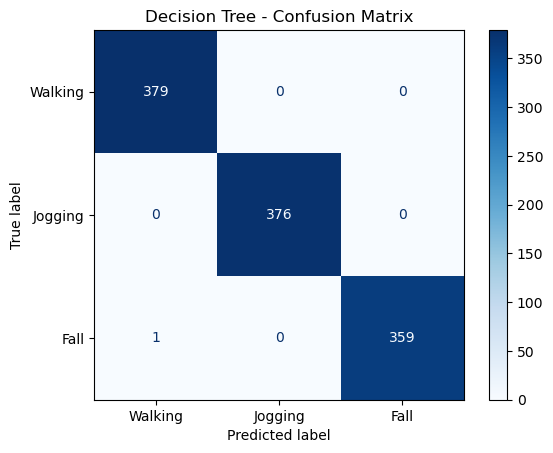

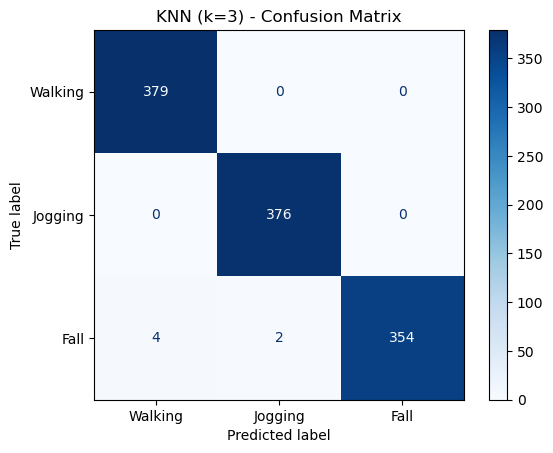

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in models.items():
    y_pred = model.predict(X_test)
    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=class_names, cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


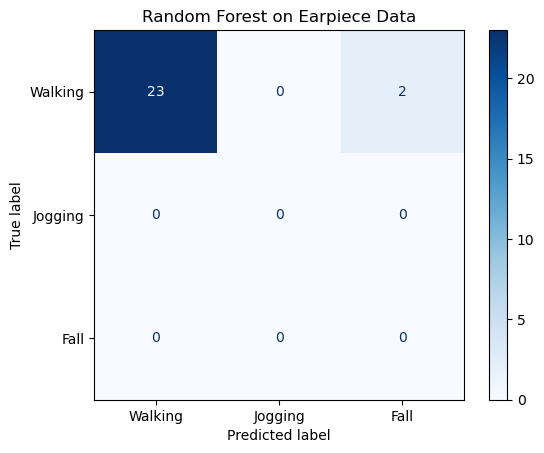

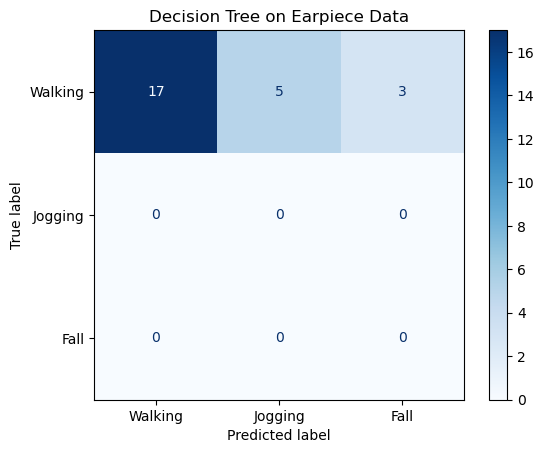

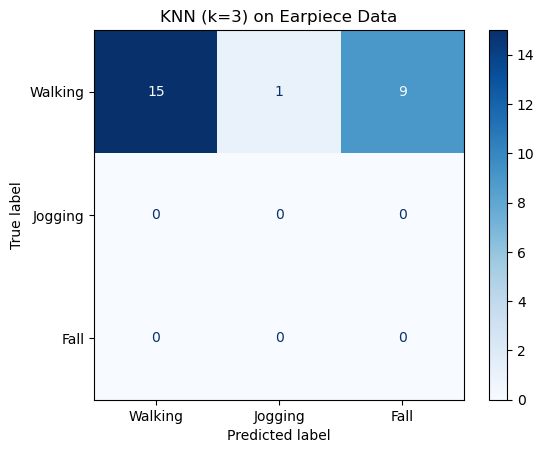

In [39]:
# Reshape flat segments back to (3, 800) and extract features
test_feature_matrix = np.array([
    extract_features(segment.reshape(3, 800)) for segment in test_data_array
])


for name, model in models.items():
    test_predictions = model.predict(test_feature_matrix)
    predicted_activities = [class_names[p] for p in test_predictions]
    # print(f"\n{name} predictions:")
    # print(predicted_activities)

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# y_true_earpiece is walking (0) for all segments in earpiece data
y_true_earpiece = [0] * len(test_predictions)  # Assuming all e

for name, model in models.items():
    test_predictions = model.predict(test_feature_matrix)
    cm = confusion_matrix(y_true_earpiece, test_predictions, labels=[0,1,2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{name} on Earpiece Data")
    plt.show()


In [25]:
earpiece_data_new_1 = pd.read_csv('earpiece/fall_1.csv')
earpiece_data_new_2 = pd.read_csv('earpiece/fall_2.csv')
earpiece_data_new_3 = pd.read_csv('earpiece/fall_3.csv')
earpiece_data_new_4 = pd.read_csv('earpiece/fall_4.csv')

list_of_earpiece_data = [earpiece_data_new_1, earpiece_data_new_2, earpiece_data_new_3, earpiece_data_new_4]

e_data_new = [data[['X', 'Y', 'Z']].T.values for data in list_of_earpiece_data]


Random Forest predictions on new earpiece data:
['Fall', 'Fall', 'Fall', 'Fall']


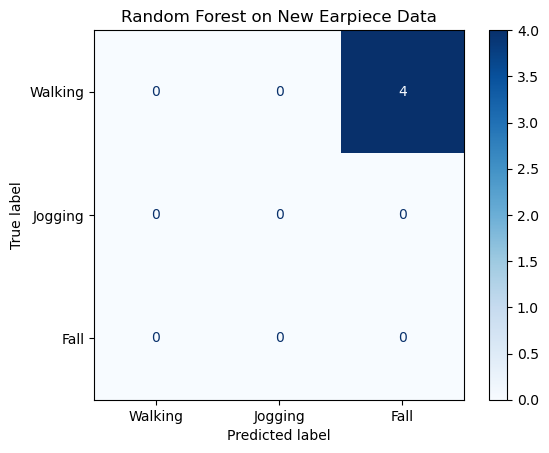


Decision Tree predictions on new earpiece data:
['Fall', 'Fall', 'Fall', 'Fall']


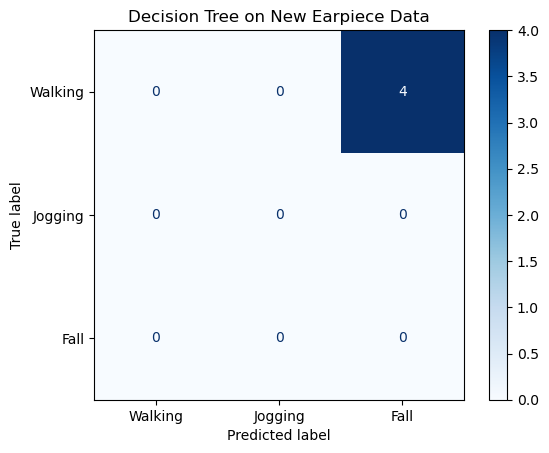


KNN (k=3) predictions on new earpiece data:
['Fall', 'Fall', 'Fall', 'Fall']


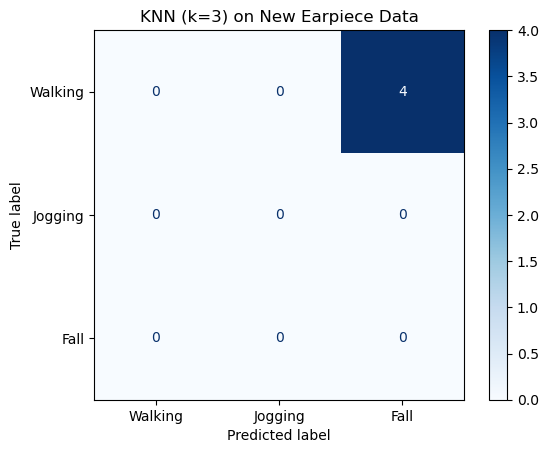

In [40]:
# extract features and test with models
e_feature_matrix = np.array([extract_features(segment) for segment in e_data_new])

for name, model in models.items():
    e_predictions = model.predict(e_feature_matrix)
    predicted_activities = [class_names[p] for p in e_predictions]
    print(f"\n{name} predictions on new earpiece data:")
    print(predicted_activities)

    # Plot confusion matrix for new earpiece data
    cm = confusion_matrix([0] * len(e_predictions), e_predictions, labels=[0,1,2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{name} on New Earpiece Data")
    plt.show()